In [1]:
"""fichier dans lequel on va récuperer les données OHLCV pour ensuite calculer les features et construire ainsi le dataset de notre projet"""

import yfinance as yf #pour télécharger les market datas
import pandas as pd
import numpy as np
from dataset_functions import add_features, create_labels
import matplotlib.pyplot as plt

df = yf.download("AAPL", start="2010-01-01", end="2024-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


df = add_features(df)          # toutes les features
df = create_labels(df, horizon=10)   # labels basés sur le futur

df = df.dropna()               # nettoyage

X = df[[
    "ret_1", "ret_5", "ret_10",
    "vol_5", "vol_20",
    "close_sma10", "close_sma20",
    "rsi", "macd", "macd_signal",
    "atr", "obv", "bb_pos"
]]

[*********************100%***********************]  1 of 1 completed


In [46]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3492 entries, 2010-02-02 to 2023-12-14
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          3492 non-null   float64
 1   High           3492 non-null   float64
 2   Low            3492 non-null   float64
 3   Open           3492 non-null   float64
 4   Volume         3492 non-null   int64  
 5   ret_1          3492 non-null   float64
 6   ret_5          3492 non-null   float64
 7   ret_10         3492 non-null   float64
 8   vol_5          3492 non-null   float64
 9   vol_20         3492 non-null   float64
 10  sma_10         3492 non-null   float64
 11  sma_20         3492 non-null   float64
 12  close_sma10    3492 non-null   float64
 13  close_sma20    3492 non-null   float64
 14  macd           3492 non-null   float64
 15  macd_signal    3492 non-null   float64
 16  rsi            3492 non-null   float64
 17  tr             3492 non-null   float64
 18  a

In [41]:
capital = 1.0
capital_evo = [capital]
i = 0
h = 10

while i < len(df) - h:
    label = df.iloc[i]["label"]
    ret = df.iloc[i]["future_return"]

    if label == "acheter":
        capital *= (1 + ret)
        capital_evo.append(capital)
    elif label == "vendre":
        capital *= (1 - ret)
        capital_evo.append(capital)

    i += h  # avancer de h jours


In [42]:
print("Retour cumulé :", capital - 1)

Retour cumulé : 206676.34409112995


<Axes: xlabel='Date'>

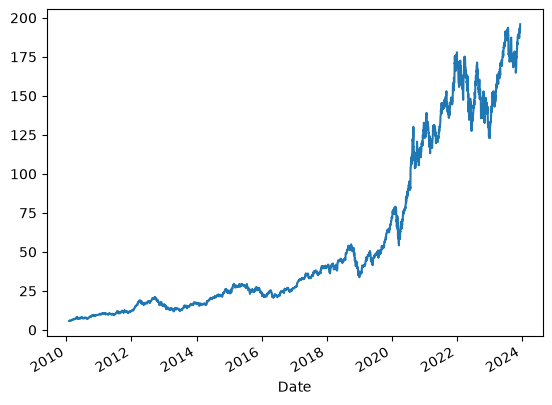

In [43]:
df["Close"].plot()

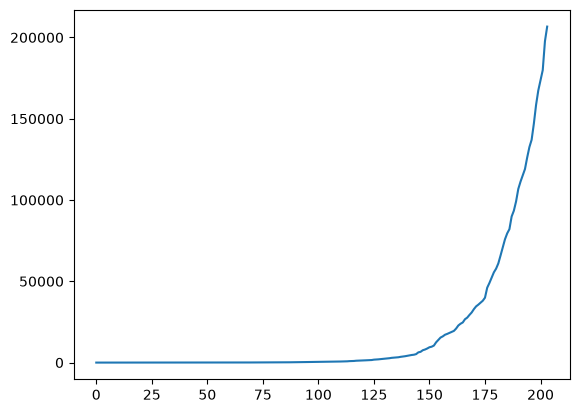

In [44]:
plt.plot(capital_evo)

In [45]:
[c for c in capital_evo if c < 1]

[]

In [33]:
df["label"].value_counts()


label
garder     1464
acheter    1287
vendre      741
Name: count, dtype: int64

In [34]:
df["label"].value_counts(normalize=True)


label
garder     0.419244
acheter    0.368557
vendre     0.212199
Name: proportion, dtype: float64

In [35]:
df[df["label"] == "vendre"]["future_return"].describe()


count    741.000000
mean      -0.063577
std        0.029019
min       -0.206864
25%       -0.078016
50%       -0.056694
75%       -0.041352
max       -0.030028
Name: future_return, dtype: float64

In [36]:
df["Close"].pct_change().corr(df["future_return"])


np.float64(-0.018965434020206434)